<a href="https://colab.research.google.com/github/vtu26063-AIML/Deep-Learning-Lab/blob/main/TASK10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

TensorFlow executing eagerly: True


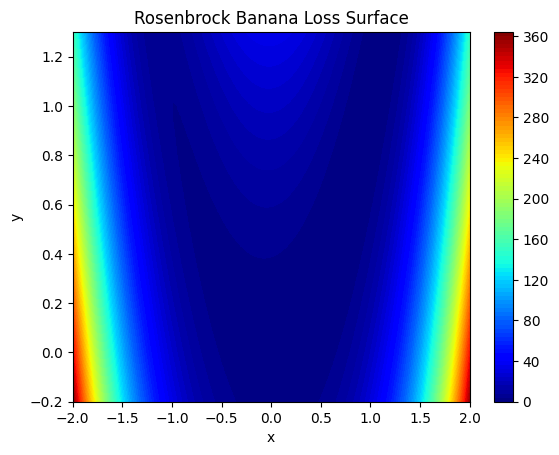

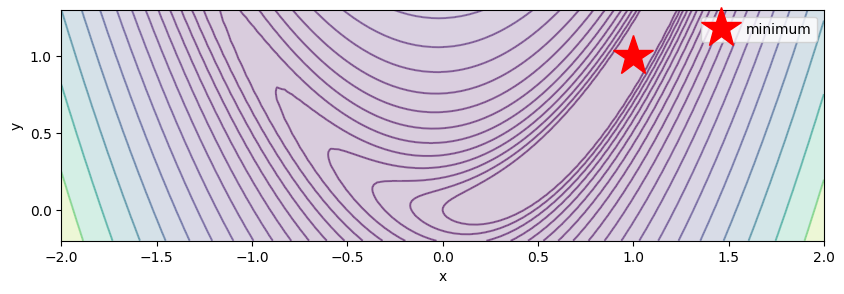

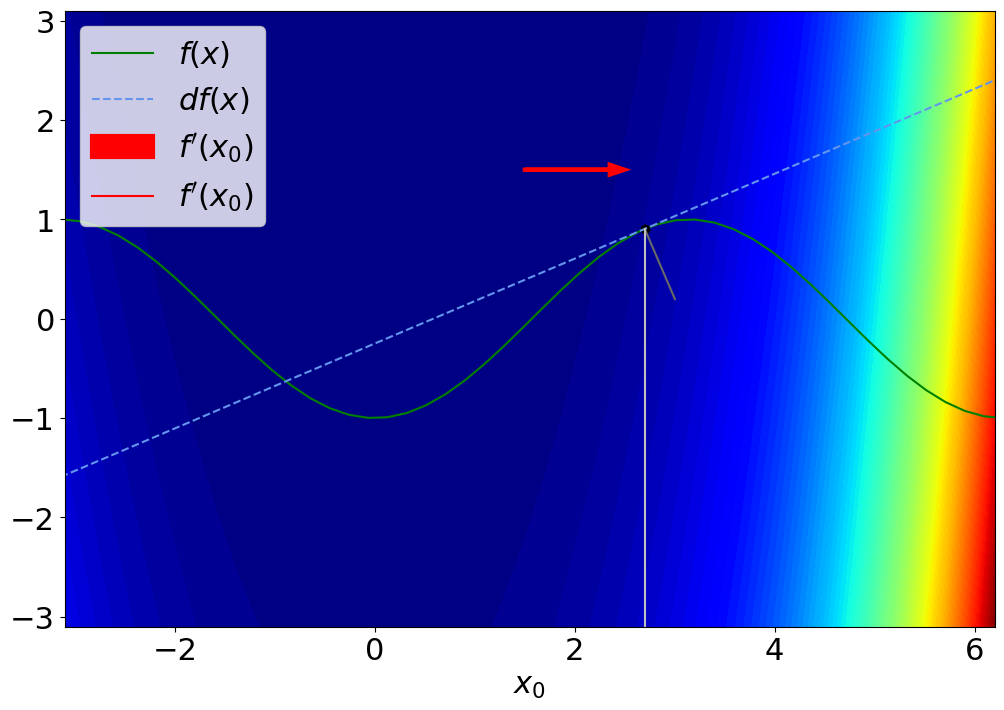

NameError: name 'min_x' is not defined

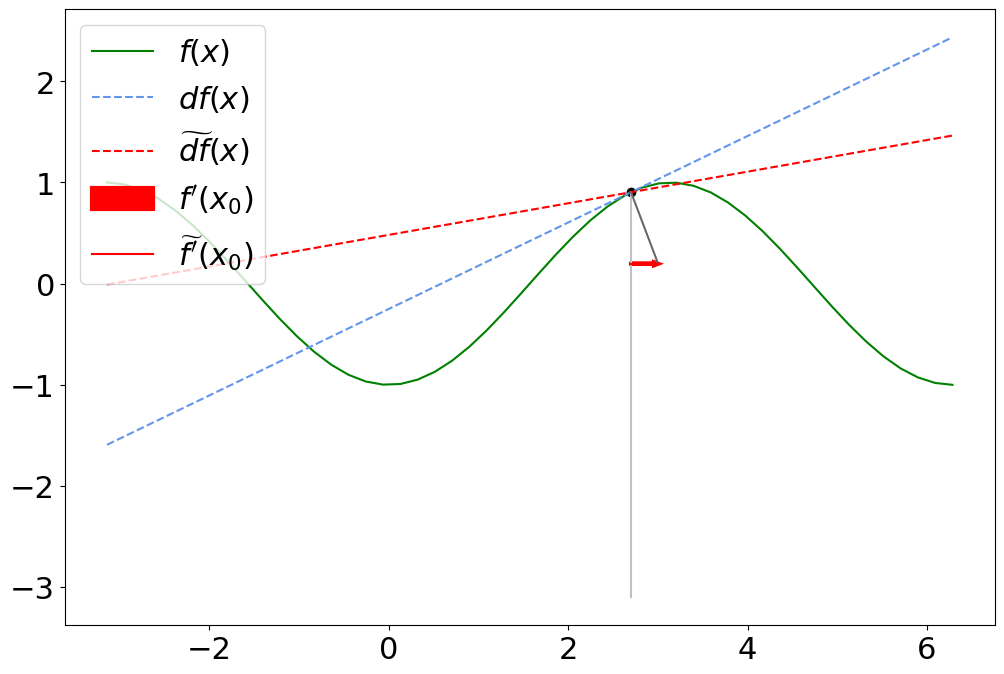

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from IPython import display
# %matplotlib inline
display.clear_output()
print("TensorFlow executing eagerly: {}".format(tf.executing_eagerly()))

def rosenbrock_banana(x, y, a=1., b=20.):
  return tf.math.pow(a - x, 2.) + b * tf.math.pow(y - tf.math.pow(x, 2.), 2.)

def gen_2d_loss_surface(loss_func, n_x=100, n_y=100, min_x=-2., max_x=2., min_y=-0.2, max_y=1.3):
  x_vals = np.linspace(min_x, max_x, n_x)
  y_vals = np.linspace(min_y, max_y, n_y)
  X, Y = np.meshgrid(x_vals, y_vals)
  Z = loss_func(X, Y)
  return X, Y, Z

# Usage example:
X, Y, Z = gen_2d_loss_surface(rosenbrock_banana)
plt.contourf(X, Y, Z, levels=100, cmap='jet')
plt.colorbar()
plt.xlabel('x')
plt.ylabel('y')
plt.title('Rosenbrock Banana Loss Surface')
plt.show()

def make_contour_plot(X, Y, Z, levels=None):
  if levels == None:
    # generate 20 levels on a log scale
    levels = np.insert(np.logspace(0, 2.6, 20, True, base=10), 0, 0)
  fig = plt.figure(figsize=(9.84, 3))
  ax = fig.gca()
  ax.contour(X, Y, Z, levels, alpha=0.5)
  ax.contourf(X, Y, Z, levels, alpha=0.2)
  ax.set_xlabel('x')
  ax.set_ylabel('y')
  return fig, ax

def make_surface_plot(X, Y, Z, elevation=0, azimuth_angle=0, levels=None):
  if levels == None:
    # generate 20 levels on a log scale
    levels = np.insert(np.logspace(0, 2.6, 20, True, base=10), 0, 0)
  fig = plt.figure(figsize=(10,6))
  ax = fig.gca(projection='3d')
  ax.view_init(elevation, azimuth_angle)

  ax.plot_surface(X, Y, Z, cmap='viridis', alpha=0.2)
  ax.contour(X, Y, Z, levels, cmap='viridis', alpha=0.5)
  ax.set_xlabel('x')
  ax.set_ylabel('y')
  return fig, ax

X, Y, Z = gen_2d_loss_surface(rosenbrock_banana)
fig, ax = make_contour_plot(X, Y, Z)
# add a marker to show the minimum
ax.plot(1, 1, 'r*', ms=30, label='minimum')
ax.legend()
fig.show()

def f(x):
  return -np.cos(x)

def tangent_f(x):
  return np.sin(x)

def df(x, x_0):
  return tangent_f(x_0) * (x - x_0) + f(x_0)

def perpindicular_unit_f(x_0):
  slope_f = tangent_f(x_0)
  y_0 = f(x_0)
  x_1 = slope_f / np.sqrt(2) + x_0
  y_1 = -x_1 / slope_f + y_0 + x_0 / slope_f
  return [[x_0, x_1], [y_0, y_1]]

def interactive_gradient_visual(x_0):
  # change the fontsize for better visibility
  init_size = plt.rcParams["font.size"] # store initial font size
  plt.rcParams.update({'font.size': 22}) # update the size
  plt.figure(figsize=(12, 8))
  x = np.linspace(-np.pi, 2 * np.pi)
  f_x = f(x)
  # plot f(x)

  plt.plot(x, f_x, label=r"$f(x)$", color="green")
  # add a point showing where x_0 falls on f(x)
  plt.plot(x_0, f(x_0), marker="o", color="black")
  # plot the tangent line to f(x) at x_0
  plt.plot(x, df(x, x_0), linestyle="--", color="cornflowerblue", label=r"$df(x)$")
  # plot the normal vector to the tangent
  perp_unit_vector = perpindicular_unit_f(x_0)
  plt.plot(perp_unit_vector[0], perp_unit_vector[1], color="dimgray")
  # drop a vertical line from x_0
  plt.plot([x_0, x_0], [f(x_0), -3.1], color="silver")
  # Usage example:
  min_x, max_x = -3.1, 6.2
  min_y, max_y = -3.1, 3.1
  X, Y, Z = gen_2d_loss_surface(rosenbrock_banana, n_x=100, n_y=100, min_x=min_x, max_x=max_x, min_y=min_y, max_y=max_y)
  plt.contourf(X, Y, Z, levels=100, cmap='jet')
  # Define the perp_unit_vector (this is just an example; you need to calculate it based on your specific scenario)
  perp_unit_vector = [[1.5, 2.5], [1.5, 1.5]]
  [[x_0, x_1], [y_0, y_1]] = perp_unit_vector
  dx = x_1 - x_0
  dy = 0 # y_1 - y_1
  arrow = plt.arrow(
      x_0, y_1, dx, dy,
      color="red", label=r"$f'(x_0)$",
      lw=3, head_width=np.abs(x_1 - x_0)/10,
      length_includes_head=True
  )

  plt.plot([x_0, x_1], [y_1, y_1], color="red", label=r"$f'(x_0)$")
  plt.legend(loc="upper left")
  plt.xlim(min_x, max_x)
  plt.ylim(min_y, max_y)
  plt.xlabel(r"$x_0$")

  plt.show()
  # Add the following line to store and reset the initial font size
  init_size = plt.rcParams['font.size']
  plt.show()
  # Reset to the initial font size (you may skip this line if you don't want to reset it)
  plt.rcParams.update({'font.size': init_size})
x_0 = 2.7
interactive_gradient_visual(x_0)

def f(x):
  return -np.cos(x)

def tangent_f(x):
  return np.sin(x)

def df(x, x_0):
  return tangent_f(x_0) * (x - x_0) + f(x_0)

def perpindicular_unit_f(x_0):
  slope_f = tangent_f(x_0)
  y_0 = f(x_0)
  x_1 = slope_f / np.sqrt(2) + x_0
  y_1 = -x_1 / slope_f + y_0 + x_0 / slope_f
  return [[x_0, x_1], [y_0, y_1]]

def noisy_df(x, x_0, noisy_x_0):
  return tangent_f(noisy_x_0) * (x - x_0) + f(x_0)

def noisy_perpindicular_unit_f(x_0, noisy_x_0):
  slope_f = tangent_f(noisy_x_0)
  y_0 = f(x_0)
  x_1 = slope_f / np.sqrt(2) + x_0
  y_1 = -x_1 / slope_f + y_0 + x_0 / slope_f
  return [[x_0, x_1], [y_0, y_1]]

def interactive_noisy_gradient_visual(x_0, noisy_x_0):
  # change the fontsize for better visibility
  init_size = plt.rcParams["font.size"] # store initial font size
  plt.rcParams.update({'font.size': 22}) # update the size

  plt.figure(figsize=(12, 8))
  x = np.linspace(-np.pi, 2 * np.pi)
  f_x = f(x)
  y_0 = f(x_0)
  # plot f(x)
  plt.plot(x, f_x, label=r"$f(x)$", color="green")
  # add a point showing where x_0 falls on f(x)
  plt.plot(x_0, f(x_0), marker="o", color="black")
  # plot the tangent line to f(x) at x_0
  plt.plot(x, df(x, x_0), linestyle="--", color="cornflowerblue", label=r"$df(x)$")
  # drop a vertical line from x_0
  plt.plot([x_0, x_0], [f(x_0), -3.1], color="silver")
  # plot the noisy tangent line to f(x) at x_0
  plt.plot(x, noisy_df(x, x_0, noisy_x_0), linestyle="--", color="red", label=r"$\widetilde{df}(x)$")
  # plot the normal vector to the tangent
  [[x_0, x_1], [y_0, y_1]] = perpindicular_unit_f(x_0)
  plt.plot([x_0, x_1], [y_0, y_1], color="dimgray")
  # Plot the noisy positive direction of the change vector
  dx = x_1 - x_0
  dy = 0
  arrow = plt.arrow(
      x_0, y_1, dx, dy,
      color="red", label=r"$f'(x_0)$",
      lw=3, head_width=np.abs(x_1 - x_0)/10,
      length_includes_head=True
  )

  plt.plot([x_0, x_1], [y_1, y_1], color="red", label=r"$\widetilde{f'}(x_0)$")
  plt.legend(loc="upper left")
  plt.xlim(min_x, max_x)
  plt.ylim(min_y, max_y)
  plt.xlabel(r"$x_0$")
  plt.show()

  # reset to initial font size
  plt.rcParams.update({'font.size': init_size})

def interactive_batch_size_visual(x_0, batch_size):
  np.random.seed(0)
  noisy_x_0 = x_0 + np.mean(np.random.normal(loc=0, scale=0.5, size=batch_size))
  interactive_noisy_gradient_visual(x_0, noisy_x_0)

batch_size = 20
interactive_batch_size_visual(x_0, batch_size)

def SGD_update(params, grads, states, hyper_params):
  # hyper-param typical values: learning_rate=0.01
  # SGD doesn't have any state, however, the algorithms
  # we will look at later do!
  for param, grad in zip(params, grads):
    param.assign_sub(hyper_params['lr'] * grad)

def optimize_banana(update_func, params, states, hyper_params):
  # plot the loss surface, minimum value and starting point
  X, Y, Z = gen_2d_loss_surface(rosenbrock_banana)
  fig, ax = make_contour_plot(X, Y, Z)
  ax.plot(1, 1, 'r*', ms=30, label='minimum')
  ax.plot(start_x, start_y, 'b*', ms=20, label='start')
  for epoch in range(epochs):
    with tf.GradientTape() as tape:
      # we are trying to minimize the output of the  func
      loss = rosenbrock_banana(x, y)
    # calculate the gradients of the loss with respect to the params
    grads = tape.gradient(loss, params)
    # save the old x and y values for the plot
    old_x = params[0].numpy()
    old_y = params[1].numpy()
    # update the parameters using SGD

    update_func(params, grads, states, hyper_params)
    # plot the change in x and y for each update step
    ax.annotate('', xy=(x.numpy(), y.numpy()),
                xytext=(old_x, old_y), arrowprops={'arrowstyle': '->', 'color': 'k', 'lw': 1},
                va='center', ha='center')
  ax.plot(x.numpy(), y.numpy(), 'g*', ms=20, label='end')
  ax.legend()
  fig.show()

start_x = -1
start_y = 0.73334
learning_rate = 0.015
epochs = 150
x = tf.Variable(start_x, dtype='float32')
y = tf.Variable(start_y, dtype='float32')
params = [x, y]
states = []
hyper_params = {"lr": learning_rate}
optimize_banana(SGD_update, params, states, hyper_params)